# 第073课 真实执行实验

聚类验证：先手算再比较结构、稳定性、负对照和下游任务。

本Notebook读取经摘要核验的原创CSV，真正执行算法；冻结输出便于离线阅读。建议重启内核后Run All。

In [1]:
import numpy as np  # 数组运算库。
from common import load_data  # 同时核验摘要和生成器字节。
data = load_data()  # 读取本讲数据，不访问网络。
print({name: len(rows['id']) for name, rows in data.items()})  # 核对对象数量。

{'development': 240, 'audit': 240, 'null': 240}


## 先预测，再算小例子

请先在纸上写出预期，再执行下一格；讲义和答案册解释每项。

In [2]:
from validation import silhouette, adjusted_rand  # 导入从定义实现的指标。
print(silhouette([[0], [1], [5], [6]], [0, 0, 1, 1]))  # 对照手算四个轮廓。
print(adjusted_rand([0, 0, 1, 1], [0, 1, 0, 1]))  # 交叉分区为-0.5。

[0.81818182 0.77777778 0.77777778 0.81818182]
-0.49999999999999994


## 执行完整冻结协议

下面调用run重新计算所有结果，未直接用冻结JSON充当实验输出。

In [3]:
from experiment import run  # 导入本讲完整实验。
report = run()  # 实际执行拟合、对照与评价。
print(report['selection'])
print(report['stability'])
print(report['null'])
print(report['downstream_mse'])

[{'k': 2, 'silhouette': 0.5614365359405374, 'ari': 0.5752716719025709}, {'k': 3, 'silhouette': 0.715057204001073, 'ari': 1.0}, {'k': 4, 'silhouette': 0.5791057915953065, 'ari': 0.8667809753199525}, {'k': 5, 'silhouette': 0.4606201640479249, 'ari': 0.7408709856781208}, {'k': 6, 'silhouette': 0.32921265647669384, 'ari': 0.5694496904963463}]
[0.9875534124710015, 1.0, 0.9875534124710015, 1.0, 0.9875534124710015, 1.0, 1.0, 1.0, 1.0, 0.9875534124710015, 1.0, 1.0, 1.0, 0.9875534124710015, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[{'k': 2, 'silhouette': 0.34012976272160866, 'stability_mean': 0.9212682509881975}, {'k': 3, 'silhouette': 0.35212610582284126, 'stability_mean': 0.7170679973016759}, {'k': 4, 'silhouette': 0.35616863165200546, 'stability_mean': 0.7893778514471871}, {'k': 5, 'silhouette': 0.32701697510106403, 'stability_mean': 0.7326279451572761}, {'k': 6, 'silhouette': 0.3390103555145906, 'stability_mean': 0.6048911442852074}]
{'global_mean': 28.88705233999532, 'cluster_mean': 2.418634224549194

## 保存本次重算结果并核对性质

显式测试含独立实现、数学恒等式和必要边界，错误会抛出异常。

In [4]:
from common import write_json  # 保存便于追查的本次结果。
write_json('outputs/notebook/result.json', report)  # 不覆盖公开冻结报告。
import subprocess, sys  # 新进程运行显式测试。
completed = subprocess.run([sys.executable, 'test_experiment.py', '--report', 'outputs/notebook/result.json', '--out', 'outputs/notebook/tests.json'], check=True, capture_output=True, text=True)
print('本次Notebook重算结果已通过显式测试。')

本次Notebook重算结果已通过显式测试。


## 重新绘图并内嵌

图从本次重算报告与原创数据生成。中文图题及每个坐标含义见讲义对应段落。

01_structures.png


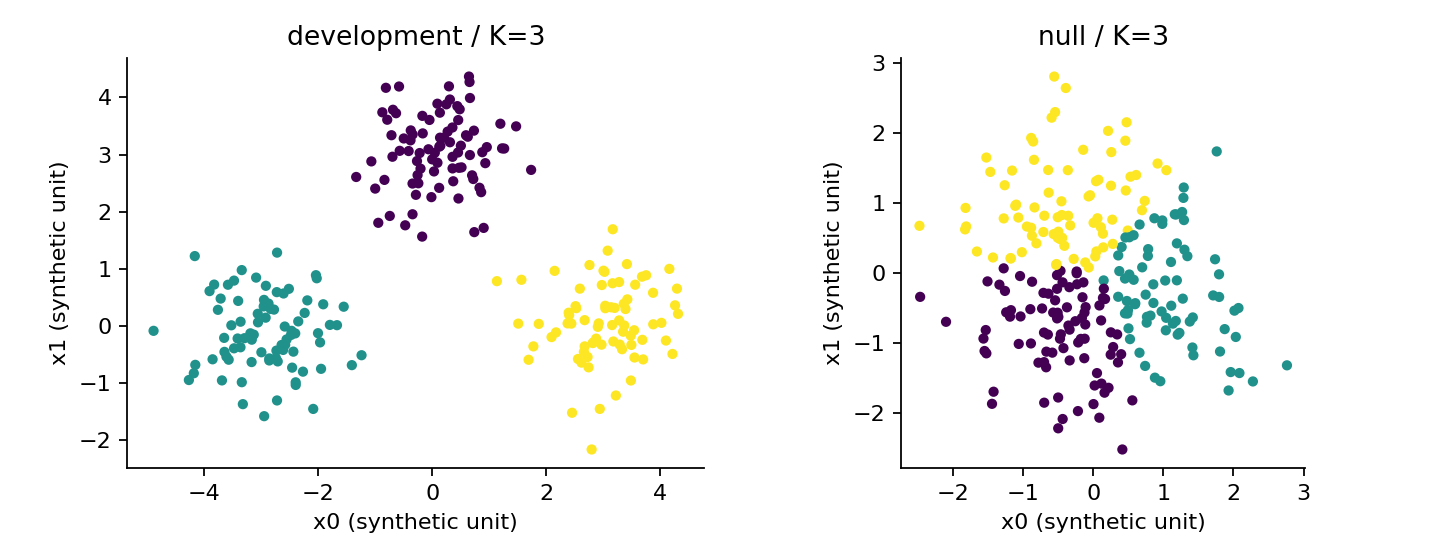

02_metrics.png


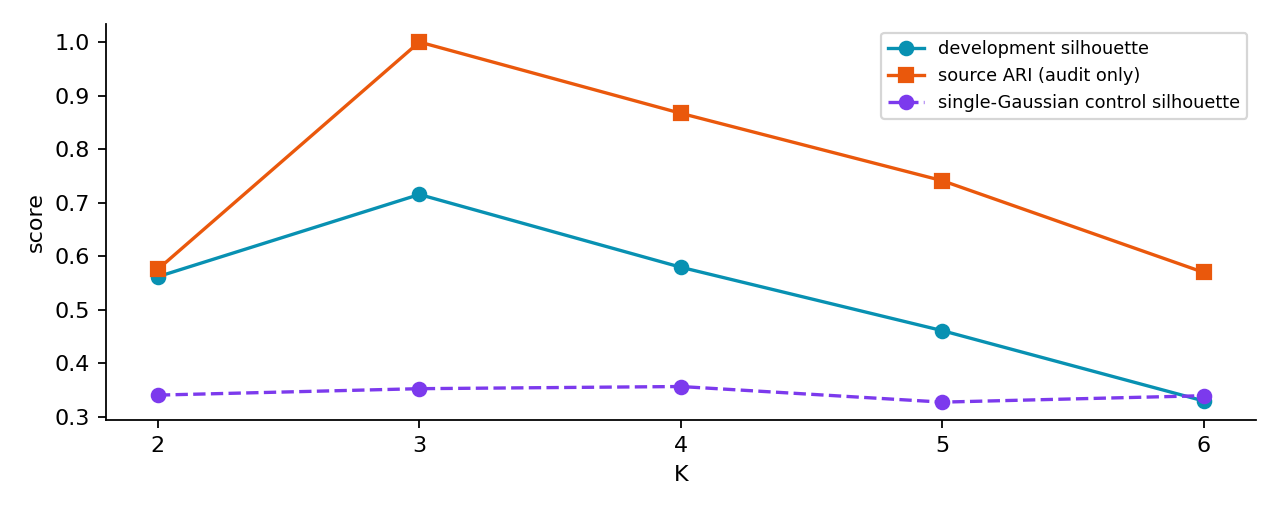

03_stability.png


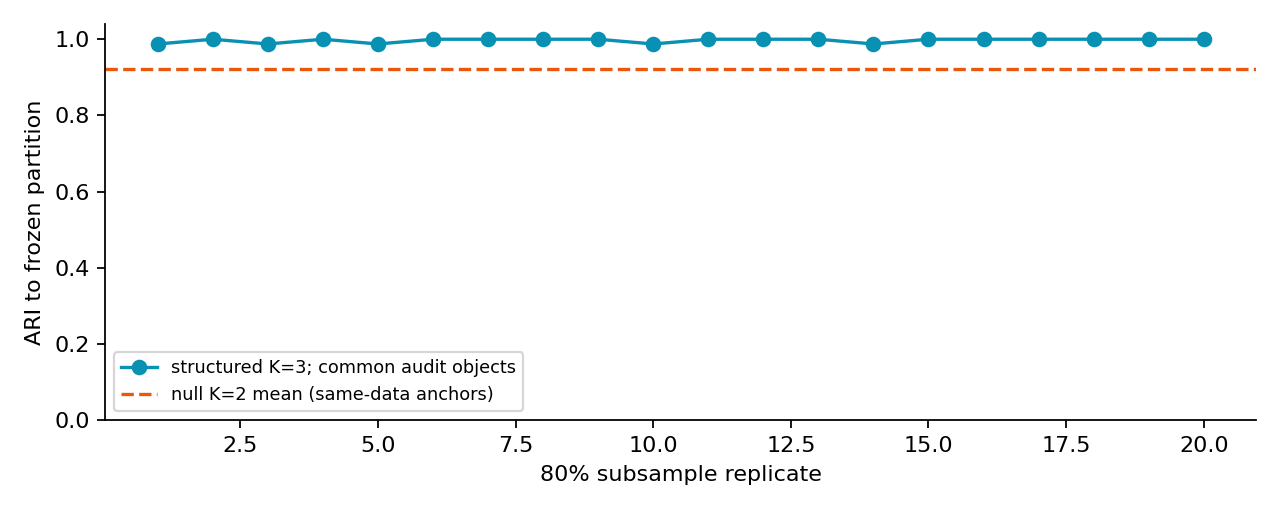

04_downstream.png


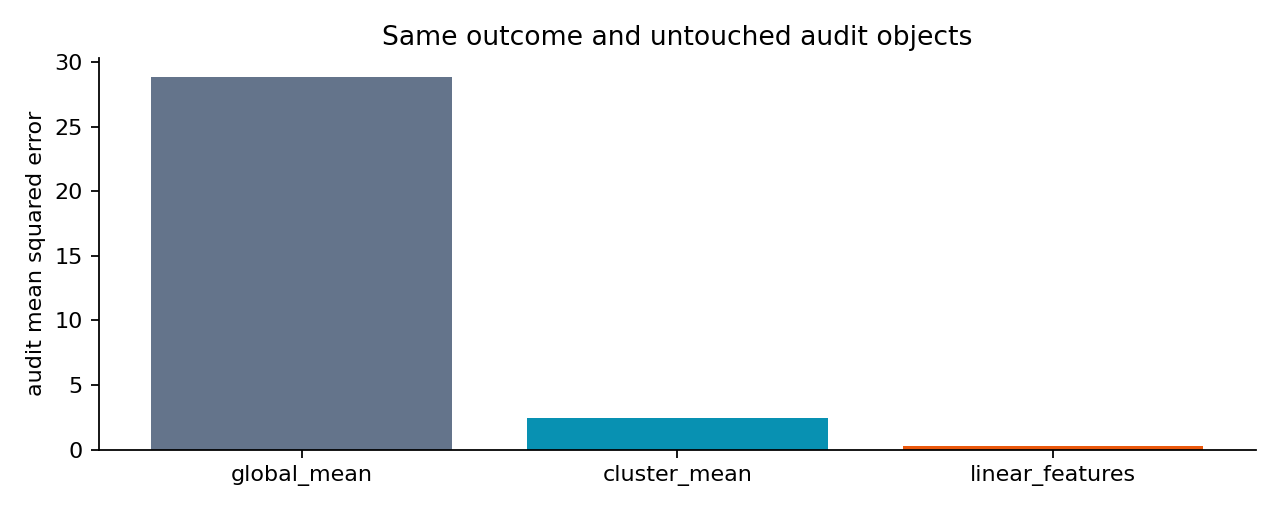

In [5]:
subprocess.run([sys.executable, 'plots.py', '--report', 'outputs/notebook/result.json', '--directory', 'outputs/notebook/figures'], check=True, capture_output=True, text=True)  # 独立绘图进程。
from pathlib import Path  # 枚举生成图。
from IPython.display import display, Image  # 嵌入PNG，不依赖外部链接。
for path in sorted(Path('outputs/notebook/figures').glob('*.png')):
    print(path.name)  # 文件名帮助对应讲义图题。
    display(Image(filename=str(path)))  # 图像数据保存在执行输出内。

## 写下你的边界声明

用一句话说明本实验已支持什么，再用一句话说明尚不能据此推出什么。请对照独立答案册，而不是只写“测试通过”。

执行验证不包含Jupyter浏览器界面和外部socket内核传输；本Notebook采用新Python进程中的真实IPython计算内核。